# 🚗 Car Position and Velocity Estimation using Data Assimilation

In this problem, we simulate the motion of a car in one dimension. The state of the system consists of two variables:

- **Position** \([m]\)
- **Velocity** \([m/s]\)

The system evolves in time according to a simple kinematic model, assuming constant velocity. However, only **noisy position observations** are available at discrete time steps.

The goal is to use different data assimilation methods (e.g., Nudging, Kalman Filter, Ensemble Kalman Filter) to estimate the true position and velocity of the car more accurately by combining:

- A **model prediction** of the system's behavior, and  
- **Partial and noisy observations** (only the position)

This setup allows us to compare the effectiveness of various assimilation methods in filtering out noise and reconstructing unobserved state variables (like velocity) from incomplete data.


## 🧩 Covariance Matrices in Kalman Filter vs Variational Methods

Data assimilation methods use covariance matrices to represent uncertainty,  
but their meanings differ between **probabilistic filters** (KF, EnKF)  
and **variational schemes** (3D-Var, 4D-Var).

---

### 🔹 1. Kalman Filter (KF, EnKF)

The Kalman family explicitly models uncertainties and propagates them over time:

$$
s_k^f = F s_{k-1}^a + w_k, \quad w_k \sim \mathcal{N}(0, Q)
$$

- **Q** → *Model (process) error covariance*  
  Represents uncertainty in the model dynamics or unmodeled processes.  
  - Larger **Q** → less trust in the model → observations dominate.  
  - Smaller **Q** → more trust in the model → smoother estimate.

- **R** → *Observation error covariance*  
  Represents measurement noise in the observations.

- **P** → *Forecast/analysis error covariance*  
  Propagated and updated at every step:
  $$
  P_k^f = F P_{k-1}^a F^T + Q
  $$
  $$
  P_k^a = (I - K_k H) P_k^f
  $$

---

### 🔹 2. Variational Methods (3D-Var, 4D-Var)

Variational methods minimize a **cost function** to find the optimal state:
$$
J(s_k^a) = (s_k^a - s_k^f)^T B^{-1} (s_k^a - s_k^f) + (o_k - Hs_k^a)^T R^{-1} (o_k - Hs_k^a)
$$

- **B** → *Background (prior) error covariance*  
  Represents uncertainty in the prior (background) state before assimilation.  
  Conceptually similar to the **forecast covariance $P_f$** in the Kalman Filter.

- **R** → *Observation error covariance*  
  Same role as in KF — quantifies observation noise.

- **Q** → *Model error covariance (optional)*  
  May appear in *weak-constraint 4D-Var* to account for model errors during time evolution,  
  but is not used in basic 3D-Var or strong-constraint 4D-Var formulations.

---

### 🔸 Summary Table

<div align='center'>

| Concept                     | Kalman Filter | Variational (3D/4D-Var) | Meaning |
|------------------------------|----------------|--------------------------|----------|
| Background / prior covariance | $P^f$        | $B$                    | Uncertainty before assimilation |
| Model / process covariance    | $Q$          | *(optional in 4D-Var)*   | Model error between steps |
| Observation covariance        | $R$          | $R$                    | Measurement error |
| Analysis covariance           | $P^a$        | Derived from $B, R$    | Posterior uncertainty |

</div>

---

### ⚖️ In short:
- **Kalman filters** propagate uncertainty *step by step* using **Q**.  
- **Variational methods** assume a *static prior uncertainty* **B** and optimize globally.  
  (In weak-constraint 4D-Var, **Q** can be added to represent model errors.)


# === Shared setup: ground truth, observations, baseline forecast ===

In [74]:
# === Libraries and plotting configuration ===
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    # Do not use font.weight here: it has no effect when using LaTeX
})

np.random.seed(42)

Steps: 100  |  dt: 0.1
Total steps: 120  |  Forecast horizon: 2.0 s
Obs noise σ_y = 1.0
Process noise Q = 0.01
Matrices:
F =
 [[1.  0.1]
 [0.  1. ]] 
H =
 [[1 0]] 
B =
 [[0.05 0.  ]
 [0.   0.05]] 
R =
 [[1.]]


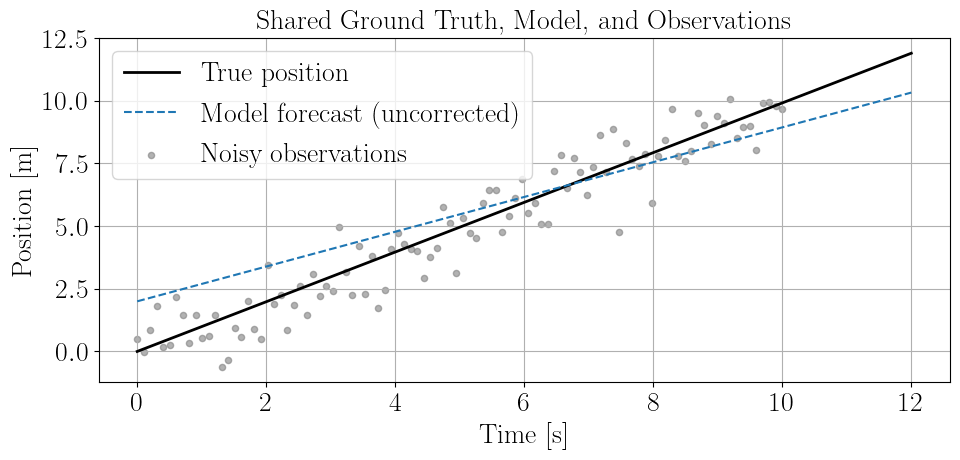

In [75]:
# ---------------------- #
#  Time configuration
# ---------------------- #
steps = 100          # number of observed steps
dt = 0.1             # time step [s]
T = steps * dt       # total observed time
extra_steps = 20     # forecast horizon beyond observations
total_steps = steps + extra_steps

# Time vectors
time = np.linspace(0, T, steps)                       # observed window
time_extended = np.linspace(0, T + extra_steps*dt, total_steps)  # full horizon

# ---------------------- #
#  Linear dynamical model
# ---------------------- #
# State: [position, velocity]
F = np.array([[1, dt],
              [0, 1]])     # transition matrix
H = np.array([[1, 0]])     # observation operator (position only)
I = np.eye(2)

# ---------------------- #
#  True state (extended)
# ---------------------- #
p0_true, v0_true = 0.0, 1.0
x_true_ext = np.zeros((total_steps, 2))
x_true_ext[0] = [p0_true, v0_true]

for k in range(1, total_steps):
    x_true_ext[k, 0] = x_true_ext[k-1, 0] + dt * x_true_ext[k-1, 1]
    x_true_ext[k, 1] = x_true_ext[k-1, 1]

# ---------------------- #
#  Observations (noisy, only over observed window)
# ---------------------- #
sigma_y = 1.0                   # observation noise std
R = np.array([[sigma_y**2]])    # observation covariance
y_obs = x_true_ext[:steps, 0] + np.random.normal(0, sigma_y, size=steps)

# ---------------------- #
#  Baseline (biased) model
# ---------------------- #
p0_mod, v0_mod = p0_true + 2.0, v0_true - 0.3  # bias for DA correction
x_model_ext = np.zeros((total_steps, 2))
x_model_ext[0] = [p0_mod, v0_mod]

for k in range(1, total_steps):
    x_model_ext[k, 0] = x_model_ext[k-1, 0] + dt * x_model_ext[k-1, 1]
    x_model_ext[k, 1] = x_model_ext[k-1, 1]

# ---------------------- #
#  Convenience shortcuts
# ---------------------- #
x_true = x_true_ext[:steps].copy()     # true trajectory (observed window)
x_model = x_model_ext[:steps].copy()   # model trajectory (observed window)

# Background (prior) covariance — used in 3DVar and 4DVar
B = np.diag([0.05, 0.05])

# Process noise covariance (used in KF/EnKF)
Q_val = 0.01
Q = np.array([[Q_val, 0.0],
              [0.0, Q_val]])

# ---------------------- #
#  Display setup summary
# ---------------------- #
print(f"Steps: {steps}  |  dt: {dt}")
print(f"Total steps: {total_steps}  |  Forecast horizon: {extra_steps*dt:.1f} s")
print(f"Obs noise σ_y = {sigma_y}")
print(f"Process noise Q = {Q_val}")
print("Matrices:\nF =\n", F, "\nH =\n", H, "\nB =\n", B, "\nR =\n", R)

# (Optional) quick visualization of the base data
plt.figure(figsize=(10,5))
plt.plot(time_extended, x_true_ext[:,0], label='True position', color='black', linewidth=2)
plt.plot(time_extended, x_model_ext[:,0], label='Model forecast (uncorrected)', linestyle='--', color='tab:blue')
plt.scatter(time, y_obs, color='gray', alpha=0.6, s=20, label='Noisy observations')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Shared Ground Truth, Model, and Observations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Nudging

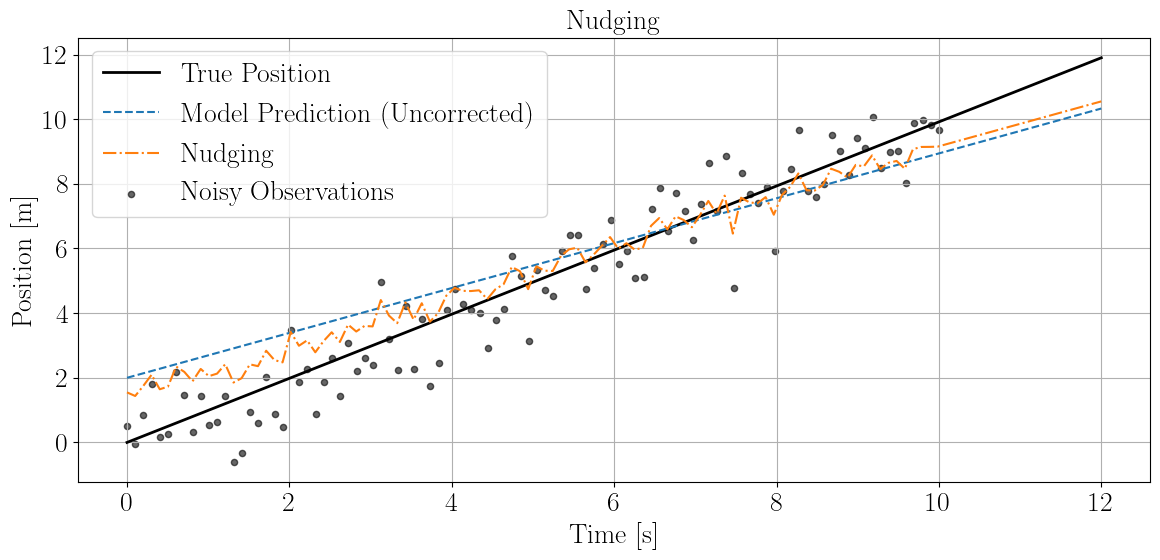

In [76]:
# === Nudging (uses shared data) ===
alpha = 0.3  # nudging gain

x_adj = x_model.copy()  # start from baseline in the observed window
for k in range(steps):
    innov = y_obs[k] - x_adj[k, 0]
    x_adj[k, 0] += alpha * innov
    # optionally: x_adj[k, 1] += beta * innov

# Extend without new observations
x_adj_ext = np.zeros((total_steps, 2))
x_adj_ext[:steps] = x_adj
for k in range(steps, total_steps):
    x_adj_ext[k] = F @ x_adj_ext[k-1]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_ext[:, 0],  label='True Position', color='black', linewidth=2)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='tab:blue')
plt.plot(time_extended, x_adj_ext[:, 0],   label='Nudging', linestyle='-.', color='tab:orange')
plt.scatter(time, y_obs, label='Noisy Observations', color='black', s=20, alpha=0.6)
plt.xlabel('Time [s]'); plt.ylabel('Position [m]'); plt.title('Nudging'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# Alpha analysis

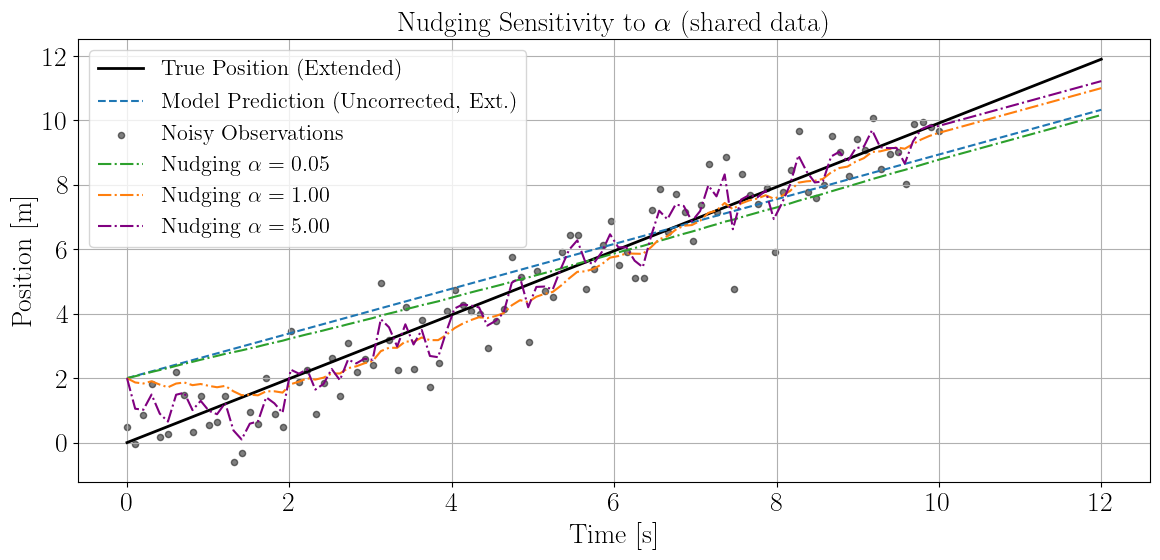

In [77]:
# --- Nudging helper: run once per alpha ---
def run_nudging(alpha):
    x_adj = np.zeros((total_steps, 2))
    x_adj[0] = x_model[0]  # mismo arranque que el baseline (ventana observada)

    # Observed window: dp/dt = v + alpha*(y - p), dv/dt = 0
    for k in range(1, steps):
        p_prev, v_prev = x_adj[k-1]
        innov = y_obs[k] - p_prev
        x_adj[k, 0] = p_prev + dt * (v_prev + alpha * innov)
        x_adj[k, 1] = v_prev

    # Extended forecast (sin nuevas observaciones): posición lineal con v constante
    p_end, v_end = x_adj[steps-1]
    if total_steps > steps:
        # posiciones futuras = p_end + v_end * dt * [1, 2, ..., extra_steps]
        future_p = p_end + dt * v_end * np.arange(1, total_steps - steps + 1)
        x_adj[steps:, 0] = future_p
        x_adj[steps:, 1] = v_end

    return x_adj[:, 0]  # devolvemos solo la posición para el plot

# --- Plot ---
plt.figure(figsize=(12, 6))

# Datos compartidos
plt.plot(time_extended, x_true_ext[:, 0],  label='True Position (Extended)',           color='black',   linewidth=2)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected, Ext.)', linestyle='--', color='tab:blue')
plt.scatter(time, y_obs, label='Noisy Observations', color='black', s=20, alpha=0.5)

# Barrido de alphas
for alpha, color in zip([0.05, 1.0, 5.0], ['tab:green', 'tab:orange', 'purple']):
    p_nudge = run_nudging(alpha)
    plt.plot(time_extended, p_nudge, label=rf'Nudging $\alpha={alpha:.2f}$', linestyle='-.', color=color)

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Nudging Sensitivity to $\\alpha$ (shared data)', fontsize=20)
plt.legend(loc='upper left', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


# Kalman Filter

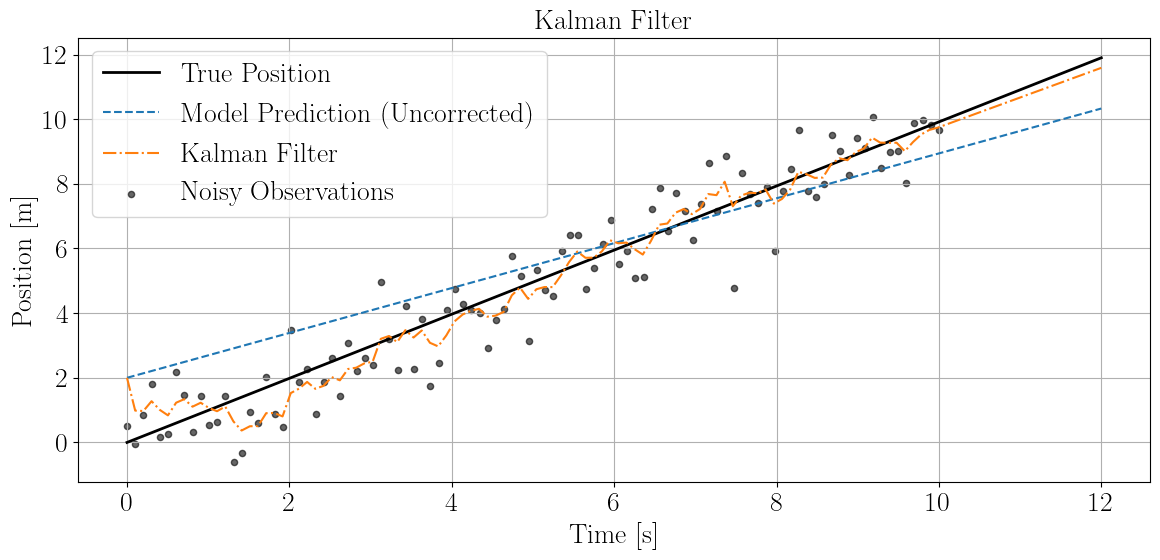

In [78]:
# === Kalman Filter (uses shared data) ===
I = np.eye(2)
x_kf = np.zeros((total_steps, 2))
x_kf[0] = x_model_ext[0]
P = np.eye(2)

for k in range(1, total_steps):
    # Predict
    x_pred = F @ x_kf[k-1]
    P_pred = F @ P @ F.T + B

    if k < steps:
        # Update
        y = y_obs[k] - (H @ x_pred)
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x_kf[k] = x_pred + (K @ y).reshape(-1)
        # Joseph form (safer); if you want the simple form, replace with P = (I - K @ H) @ P_pred
        P = (I - K @ H) @ P_pred @ (I - K @ H).T + K @ R @ K.T
    else:
        x_kf[k] = x_pred
        P = P_pred

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_ext[:, 0],  label='True Position', color='black', linewidth=2)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='tab:blue')
plt.plot(time_extended, x_kf[:, 0],        label='Kalman Filter', linestyle='-.', color='tab:orange')
plt.scatter(time, y_obs, label='Noisy Observations', color='black', s=20, alpha=0.6)
plt.xlabel('Time [s]'); plt.ylabel('Position [m]'); plt.title('Kalman Filter'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


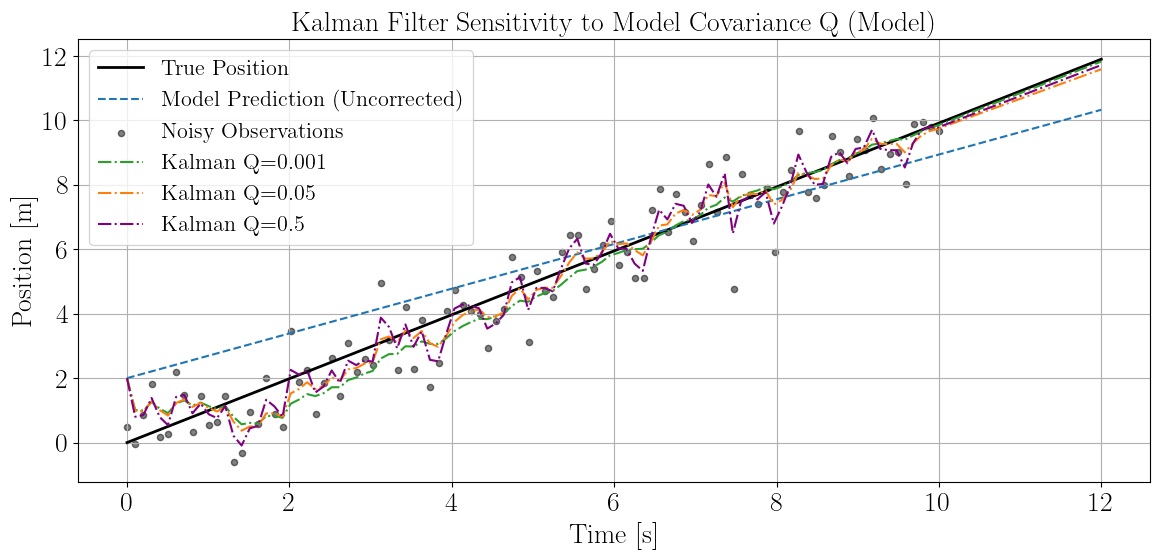

In [79]:
# --- Helper: Kalman filter for a given Q value ---
def run_kf(Q_val):
    Q = np.array([[Q_val, 0.0],
                  [0.0,   Q_val]])
    I = np.eye(2)

    x_kf = np.zeros((total_steps, 2))
    x_kf[0] = x_model_ext[0]
    P = np.eye(2)

    for k in range(1, total_steps):
        # Predict
        x_pred = F @ x_kf[k-1]
        P_pred = F @ P @ F.T + Q

        if k < steps:
            # Update
            y = y_obs[k] - (H @ x_pred)
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ np.linalg.inv(S)
            x_kf[k] = x_pred + (K @ y).reshape(-1)
            # Joseph (stable) covariance update
            P = (I - K @ H) @ P_pred @ (I - K @ H).T + K @ R @ K.T
        else:
            x_kf[k] = x_pred
            P = P_pred
    return x_kf[:, 0]  # posición

# --- Plot ---
Q_values = [0.001, 0.05, 0.5]
colors    = ['tab:green', 'tab:orange', 'purple']

plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_ext[:, 0],  label='True Position',                  color='black',   linewidth=2)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected)', linestyle='--',  color='tab:blue')
plt.scatter(time, y_obs, label='Noisy Observations', color='black', s=20, alpha=0.5)

for q, c in zip(Q_values, colors):
    p_kf = run_kf(q)
    plt.plot(time_extended, p_kf, label=f'Kalman Q={q:g}', linestyle='-.', color=c)

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Kalman Filter Sensitivity to Model Covariance Q (Model)', fontsize=20)
plt.legend(fontsize=16, loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


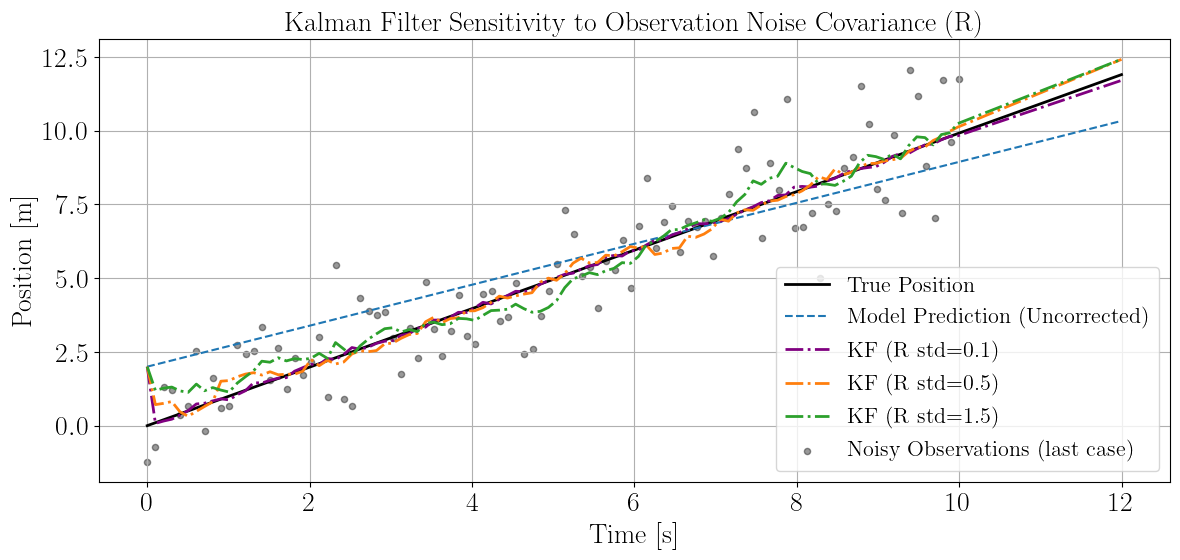

In [80]:
# --- Helper: KF with given observation noise std (sigma) ---
def run_kf_R(obs_std):
    R = np.array([[obs_std**2]])
    I = np.eye(2)

    # generate observations for this std over observed window
    y_obs_i = x_true_ext[:steps, 0] + np.random.normal(0.0, obs_std, steps)

    x_kf = np.zeros((total_steps, 2))
    x_kf[0] = x_model_ext[0]
    P = np.eye(2)

    for k in range(1, total_steps):
        # Predict
        x_pred = F @ x_kf[k-1]
        P_pred = F @ P @ F.T + Q  # Q is shared (fixed for this sweep)

        if k < steps:
            # Update
            y = y_obs_i[k] - (H @ x_pred)
            S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ np.linalg.inv(S)
            x_kf[k] = x_pred + (K @ y).reshape(-1)
            # Joseph form (stable)
            P = (I - K @ H) @ P_pred @ (I - K @ H).T + K @ R @ K.T
        else:
            x_kf[k] = x_pred
            P = P_pred

    return x_kf[:, 0], y_obs_i  # position, obs used

# --- Plot ---
obs_std_values = [0.1, 0.5, 1.5]
colors = ['purple', 'tab:orange', 'tab:green']

plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_ext[:, 0],  label='True Position',                  color='black',   linewidth=2)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected)', linestyle='--',  color='tab:blue')

y_obs_last = None
for std, color in zip(obs_std_values, colors):
    p_kf, y_obs_i = run_kf_R(std)
    plt.plot(time_extended, p_kf, linestyle='-.', linewidth=2, label=f'KF (R std={std:g})', color=color)
    y_obs_last = y_obs_i  # keep last case for scatter

plt.scatter(time, y_obs_last, label='Noisy Observations (last case)',
            color='black', s=20, alpha=0.4)

plt.xlabel('Time [s]', fontsize=20)
plt.ylabel('Position [m]', fontsize=20)
plt.title('Kalman Filter Sensitivity to Observation Noise Covariance (R)', fontsize=20)
plt.legend(fontsize=16, loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


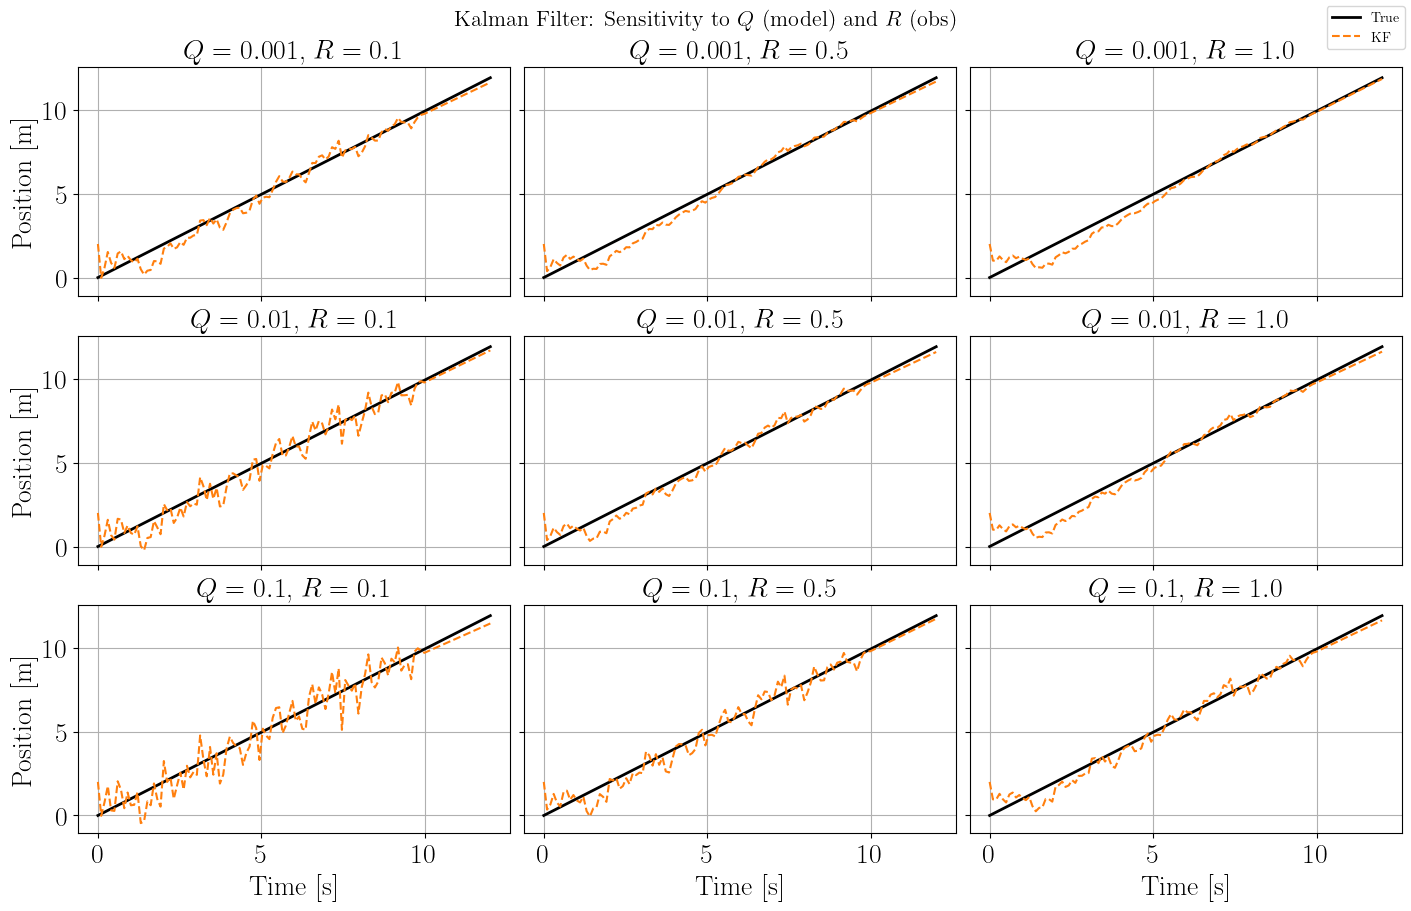

In [81]:
# === Compact Kalman Filter sensitivity (shared setup) ===
def kf_qr(q, r_std):
    Q = np.array([[q, 0.0], [0.0, q]])
    R = np.array([[r_std**2]])
    I = np.eye(2)
    x = np.zeros((total_steps, 2)); x[0] = x_model_ext[0]
    P = np.eye(2)
    for k in range(1, total_steps):
        x_pred = F @ x[k-1]; P_pred = F @ P @ F.T + Q
        if k < steps:
            y = y_obs[k] - (H @ x_pred); S = H @ P_pred @ H.T + R
            K = P_pred @ H.T @ np.linalg.inv(S)
            x[k] = x_pred + (K @ y).reshape(-1)
            P = (I - K @ H) @ P_pred @ (I - K @ H).T + K @ R @ K.T
        else:
            x[k], P = x_pred, P_pred
    return x[:, 0]

Q_vals, R_stds = [0.001, 0.01, 0.1], [0.1, 0.5, 1.0]
fig, axs = plt.subplots(len(Q_vals), len(R_stds),
                        figsize=(14, 9), sharex=True, sharey=True,
                        constrained_layout=True)

for i, q in enumerate(Q_vals):
    for j, rstd in enumerate(R_stds):
        ax = axs[i, j]
        ax.plot(time_extended, x_true_ext[:, 0], 'k', lw=2, label='True')
        ax.plot(time_extended, kf_qr(q, rstd), '--', color='tab:orange', label='KF')
        ax.set_title(rf'$Q={q}$, $R={rstd}$')
        if i == len(Q_vals)-1: ax.set_xlabel('Time [s]')
        if j == 0: ax.set_ylabel('Position [m]')
        ax.grid(True)

# Add a single shared legend only once (avoids warning)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=10)

fig.suptitle('Kalman Filter: Sensitivity to $Q$ (model) and $R$ (obs)', fontsize=16)
plt.show()


# Ensamble Kalman Filter

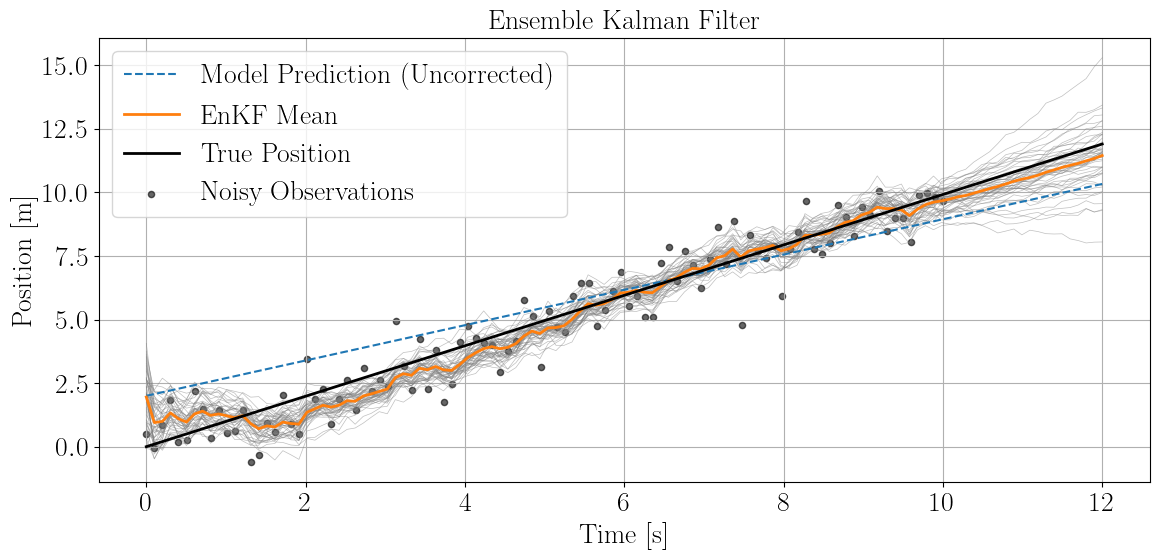

In [82]:
# === Ensemble Kalman Filter (uses shared data) ===
N = 50  # ensemble size

# Ensemble init around baseline
x_ens = np.zeros((total_steps, N, 2))
x_ens[0, :, 0] = x_model_ext[0, 0] + np.random.normal(0, 1.0, N)
x_ens[0, :, 1] = x_model_ext[0, 1] + np.random.normal(0, 0.5, N)

x_enkf_mean = np.zeros((total_steps, 2))
x_enkf_mean[0] = np.mean(x_ens[0], axis=0)

for k in range(1, total_steps):
    # Forecast
    for i in range(N):
        noise = np.random.multivariate_normal([0.0, 0.0], Q)
        x_ens[k, i] = F @ x_ens[k-1, i] + noise

    if k < steps:
        x_mean = np.mean(x_ens[k], axis=0)
        Xp = x_ens[k] - x_mean
        P_f = (Xp.T @ Xp) / (N - 1)

        # Stochastic EnKF (perturbed obs)
        y_pert = y_obs[k] + np.random.normal(0.0, np.sqrt(R[0, 0]), N)
        S = H @ P_f @ H.T + R
        K = P_f @ H.T @ np.linalg.inv(S)

        for i in range(N):
            innovation = y_pert[i] - (H @ x_ens[k, i]).item()
            x_ens[k, i] += (K @ np.array([innovation])).reshape(-1)

    x_enkf_mean[k] = np.mean(x_ens[k], axis=0)

# Plot
plt.figure(figsize=(12, 6))
for i in range(N):
    plt.plot(time_extended, x_ens[:, i, 0], color='grey', linewidth=0.5, alpha=0.5)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='tab:blue')
plt.plot(time_extended, x_enkf_mean[:, 0], label='EnKF Mean', color='tab:orange', linewidth=2)
plt.plot(time_extended, x_true_ext[:, 0], label='True Position', color='black', linewidth=2)
plt.scatter(time, y_obs, label='Noisy Observations', color='black', s=20, alpha=0.6)
plt.xlabel('Time [s]'); plt.ylabel('Position [m]'); plt.title('Ensemble Kalman Filter'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


## 3D-Var

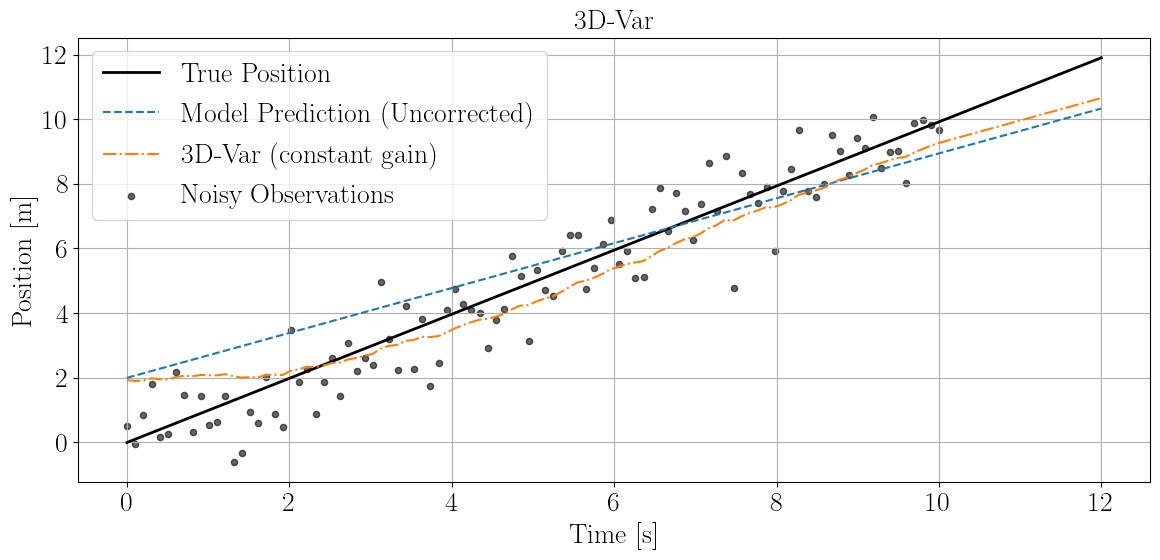

In [83]:
# === 3D-Var (constant gain, uses B and R from shared data) ===
K_3dvar = B @ H.T @ np.linalg.inv(H @ B @ H.T + R)

x_3dvar_ext = np.zeros((total_steps, 2))
# initial analysis from baseline + first obs
x_3dvar_ext[0] = x_model_ext[0] + (K_3dvar @ (y_obs[0] - H @ x_model_ext[0])).reshape(-1)

for k in range(1, steps):
    xf = F @ x_3dvar_ext[k-1]
    innov = y_obs[k] - (H @ xf)
    x_3dvar_ext[k] = xf + (K_3dvar @ innov).reshape(-1)

for k in range(steps, total_steps):
    x_3dvar_ext[k] = F @ x_3dvar_ext[k-1]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_ext[:, 0],  label='True Position', color='black', linewidth=2)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='tab:blue')
plt.plot(time_extended, x_3dvar_ext[:, 0], label='3D-Var (constant gain)', linestyle='-.', color='tab:orange')
plt.scatter(time, y_obs, label='Noisy Observations', color='black', s=20, alpha=0.6)
plt.xlabel('Time [s]'); plt.ylabel('Position [m]'); plt.title('3D-Var'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


## 4D-Var

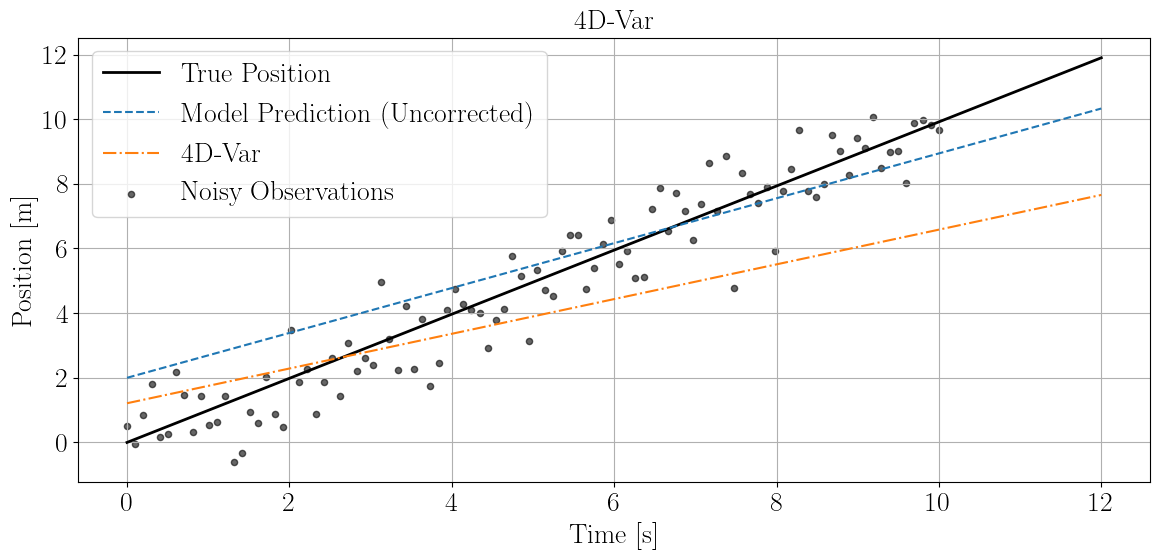

In [89]:
# === 4D-Var (estimate optimal initial state over a time window) ===
from scipy.optimize import minimize

def propagate(x0, n):
    traj = np.zeros((n, 2))
    traj[0] = x0
    for t in range(1, n):
        traj[t] = F @ traj[t-1]
    return traj

def J(x0, window):
    traj = propagate(np.asarray(x0), window)
    innov = y_obs[:window] - traj[:, 0]           # H = [1, 0]
    obs_term = np.sum((innov**2) / R[0, 0])
    back_term = (x0 - x_model_ext[0]).T @ np.linalg.inv(B) @ (x0 - x_model_ext[0])
    return 0.5 * (obs_term + back_term)

size_window = 50
window = min(size_window, steps)
res = minimize(J, x0=x_model_ext[0], args=(window,), method='L-BFGS-B')
x0_opt = res.x

x_4dvar_ext = propagate(x0_opt, total_steps)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time_extended, x_true_ext[:, 0],  label='True Position', color='black', linewidth=2)
plt.plot(time_extended, x_model_ext[:, 0], label='Model Prediction (Uncorrected)', linestyle='--', color='tab:blue')
plt.plot(time_extended, x_4dvar_ext[:, 0], label='4D-Var', linestyle='-.', color='tab:orange')
plt.scatter(time, y_obs, label='Noisy Observations', color='black', s=20, alpha=0.6)
plt.xlabel('Time [s]'); plt.ylabel('Position [m]'); plt.title('4D-Var'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
